<a href="https://colab.research.google.com/github/lsmc-isa/avcad_2026/blob/main/Ex_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0 - Upload the dataset to the environment

In [7]:
from google.colab import files
uploaded = files.upload()

# Get the name of the first (and likely only) uploaded file
zip_path = next(iter(uploaded))

Saving EFIplus_medit (1).zip to EFIplus_medit (1) (1).zip


### 1. Unzipping the uploaded file

First, we'll use Python's `zipfile` module to extract the contents of the uploaded `.zip` file. We'll extract everything into the current directory (`/content/`).

In [8]:
import zipfile
import os
import pandas as pd

# The zip_path variable from the previous cell contains the path to your uploaded zip file.
# For example: '/content/EFIplus_medit (1).zip'

# Create a directory to extract the contents into, or use the current directory.
# For simplicity, we'll extract to the current directory.
# Be careful if you have many files; it might clutter your /content folder.

print(f"Unzipping '{zip_path}'...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./')
print("Extraction complete!")

Unzipping 'EFIplus_medit (1) (1).zip'...
Extraction complete!


### 2. Listing extracted files and finding the CSV

Now that the file is unzipped, let's list all the files in the current directory (`/content/`) to see what was extracted. We'll then automatically identify the CSV file among them.

In [9]:
# List all files and directories in the current working directory
extracted_files = os.listdir('./')
print("Files extracted to /content/:")
for f in extracted_files:
    print(f)

# Automatically find the CSV file
csv_files = [f for f in extracted_files if f.lower().endswith('.csv')]

if not csv_files:
    print("No CSV files found in the extracted content.")
    csv_file_path = None
elif len(csv_files) == 1:
    csv_file_path = os.path.join('./', csv_files[0])
    print(f"Found one CSV file: '{csv_file_path}'")
else:
    print(f"Found multiple CSV files: {csv_files}. Using the first one: '{csv_files[0]}'")
    csv_file_path = os.path.join('./', csv_files[0])

Files extracted to /content/:
.config
EFIplus_medit.csv
EFIplus_medit (1) (1).zip
EFIplus_medit (1).zip
sample_data
Found one CSV file: './EFIplus_medit.csv'


### 3. Loading the CSV into a Pandas DataFrame and previewing it

Finally, we'll use the powerful `pandas` library to load the identified CSV file into a DataFrame and display its first few rows to get a quick overview of the data.

In [12]:
if csv_file_path:
    try:
        df = pd.read_csv(csv_file_path, sep=';')
        print(f"Successfully loaded '{csv_file_path}' into a pandas DataFrame.")
        print("Displaying the first 5 rows with corrected separator:")
        display(df.head())
    except Exception as e:
        print(f"Error loading CSV file '{csv_file_path}': {e}")
else:
    print("Cannot load data: No CSV file was found.")

Successfully loaded './EFIplus_medit.csv' into a pandas DataFrame.
Displaying the first 5 rows with corrected separator:


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


The dataset was successfully imported into the Colab environment.
It contains river sampling sites as rows and environmental, anthropogenic, and biological variables as columns.

At this stage, the data will be explored to understand its structure, variable types, and potential missing values before proceeding with exploratory data analysis and hypothesis testing.

### 1. Summarizing the Dataset Structure

First, we'll use `df.info()` to get a concise summary of the DataFrame. This includes the number of entries, number of columns, column names, non-null counts, and data types of each column. This gives us a quick overview of the dataset's completeness and types of data we're working with.

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB
None


### 2. Identifying Missing Values

Next, we'll check for any missing values across all columns using `df.isnull().sum()`. Knowing where and how many missing values exist is crucial for data cleaning and preprocessing.

In [14]:
print('Missing values per column:')
display(df.isnull().sum().to_frame(name='Missing Count'))

Missing values per column:


,Missing Count
Site_code,0
Latitude,0
Longitude,0
Country,0
Catchment_name,0
...,...
Zingel asper,0
Squalius sp,0
Barbatula sp,0
Phoxinus sp,0


### 3. Displaying Basic Statistics

Finally, `df.describe()` will provide descriptive statistics for numerical columns, including count, mean, standard deviation, min, max, and quartile values. For non-numerical (object or categorical) columns, it will provide count, unique values, top occurring value, and its frequency. This helps us understand the central tendency, dispersion, and shape of the data distribution.

In [15]:
print('Basic descriptive statistics for numerical columns:')
display(df.describe())

print('\nBasic descriptive statistics for non-numerical (object/categorical) columns:')
display(df.describe(include='object'))

Basic descriptive statistics for numerical columns:


,Latitude,Longitude,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,4.615000e+03,...,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000
mean,41.660286,-4.220392,0.288964,0.790860,0.278388,0.811814,0.403313,0.460387,0.497306,4.550399e-12,...,0.000399,0.085412,0.000599,0.000399,0.012373,0.000200,0.196568,0.068250,0.132708,0.031132
std,1.654641,4.754419,0.453327,0.406735,0.448250,0.390900,0.490611,0.498478,0.500043,1.000108e+00,...,0.019976,0.279522,0.024463,0.019976,0.110554,0.014127,0.397442,0.252199,0.339293,0.173690
min,36.213984,-9.459453,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.465112e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.450919,-7.716600,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.129179e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.316060,-6.176062,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.515341e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42.904789,-1.959129,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.319150e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,45.098423,15.625773,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.345204e-01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Basic descriptive statistics for non-numerical (object/categorical) columns:


,Site_code,Country,Catchment_name,Water_source_type,Flow_regime,Geological_typology
count,5011,5011,5011,4712,4473,5011
unique,5011,4,39,4,3,2
top,PTVO64,Spain,Ebro,Pluvial,Permanent,Siliceous
freq,1,3887,736,4128,3917,3315


The initial data exploration showed that the dataset contains a mixture of continuous and categorical variables describing environmental conditions and fish presence across river sampling sites.

Missing values are limited and do not compromise the analysis. The variables of interest (Temp_ann, Salmo trutta fario presence, catchment, and actual_river_slope) are well represented, allowing for subsequent exploratory analysis and hypothesis testing.

### 1. Analyzing the relationship between a continuous variable and a binary variable

We'll use `temp_ann` (annual temperature) as our continuous variable and `Salmo trutta fario` (presence/absence of a fish species) as our binary variable. A box plot is an excellent choice to visualize the distribution of a continuous variable across different categories of a binary variable.

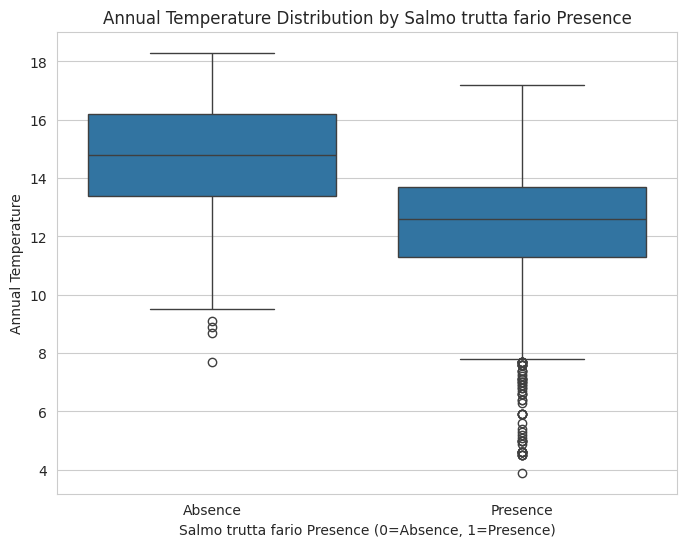

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a box plot to visualize the relationship
plt.figure(figsize=(8, 6))
sns.boxplot(x='Salmo trutta fario', y='temp_ann', data=df)
plt.title('Annual Temperature Distribution by Salmo trutta fario Presence')
plt.xlabel('Salmo trutta fario Presence (0=Absence, 1=Presence)')
plt.ylabel('Annual Temperature')
plt.xticks([0, 1], ['Absence', 'Presence']) # Label the x-axis for clarity
plt.show()

# Statistical explanation:
# A box plot displays the distribution of a continuous variable (temp_ann) for each category of a binary variable (Salmo trutta fario).
# The box represents the interquartile range (IQR), with the line inside indicating the median.
# The 'whiskers' extend to 1.5 times the IQR from the box, covering most of the data.
# Points outside the whiskers are considered outliers.
# This plot helps us visually assess differences in median temperature, spread, and skewness between sites with and without Salmo trutta fario.

### 2. Comparing this relationship across two groups and computing effect size

Now, let's examine this relationship (`temp_ann` vs. `Salmo trutta fario`) across two different groups, defined by the `Country` variable. We'll pick 'Spain' and 'Portugal' as our groups. We'll also compute Cohen's d as an effect size measure to quantify the magnitude of the difference in `temp_ann` between `Salmo trutta fario` presence/absence within each country.

<Figure size 1200x600 with 0 Axes>

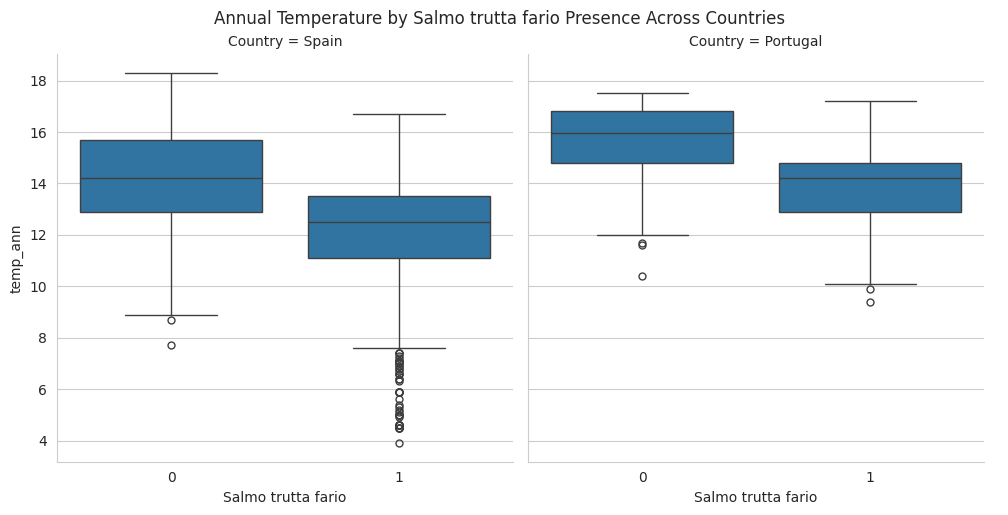


--- Cohen's d Effect Size ---
For Spain: Cohen's d for temp_ann difference (Presence vs. Absence) = -1.123
For Portugal: Cohen's d for temp_ann difference (Presence vs. Absence) = -1.379


In [17]:
import numpy as np

# Filter the DataFrame for two countries, e.g., Spain and Portugal
df_filtered = df[df['Country'].isin(['Spain', 'Portugal'])]

# Create a faceted box plot for comparison across countries
plt.figure(figsize=(12, 6))
sns.catplot(x='Salmo trutta fario', y='temp_ann', col='Country', data=df_filtered, kind='box', height=5, aspect=1)
plt.suptitle('Annual Temperature by Salmo trutta fario Presence Across Countries', y=1.02) # Adjust suptitle position
plt.show()

# Compute Cohen's d for each country
print("\n--- Cohen's d Effect Size ---")
for country in df_filtered['Country'].unique():
    country_df = df_filtered[df_filtered['Country'] == country]

    # Group by Salmo trutta fario presence/absence
    group_0 = country_df[country_df['Salmo trutta fario'] == 0]['temp_ann']
    group_1 = country_df[country_df['Salmo trutta fario'] == 1]['temp_ann']

    if len(group_0) > 1 and len(group_1) > 1: # Ensure there's enough data for calculation
        mean_0 = np.mean(group_0)
        std_0 = np.std(group_0, ddof=1) # Use ddof=1 for sample standard deviation
        n_0 = len(group_0)

        mean_1 = np.mean(group_1)
        std_1 = np.std(group_1, ddof=1)
        n_1 = len(group_1)

        # Pooled standard deviation
        pooled_std = np.sqrt(((n_0 - 1) * std_0**2 + (n_1 - 1) * std_1**2) / (n_0 + n_1 - 2))

        # Cohen's d
        if pooled_std > 0:
            cohens_d = (mean_1 - mean_0) / pooled_std
            print(f"For {country}: Cohen's d for temp_ann difference (Presence vs. Absence) = {cohens_d:.3f}")
        else:
            print(f"For {country}: Cannot compute Cohen's d (pooled standard deviation is zero).")
    else:
        print(f"For {country}: Not enough data in one or both groups to compute Cohen's d.")

# Statistical explanation:
# Faceted plots allow for visual comparison of the same relationship across different subgroups (countries).
# Cohen's d is a standardized measure of the effect size, indicating the magnitude of the difference between two means.
# It's calculated as the difference between the means divided by the pooled standard deviation.
# Interpretation:
#   - Small effect: |d| = 0.2
#   - Medium effect: |d| = 0.5
#   - Large effect: |d| = 0.8
# This helps to understand not just if there's a difference, but how substantial that difference is in a practical sense.

### 3. Testing for normal distribution using graphical and statistical methods

We'll check if the `temp_ann` variable follows a normal distribution. This is often an assumption for many statistical tests. We'll use a histogram and a Q-Q plot for graphical assessment, and the Shapiro-Wilk test for statistical confirmation.

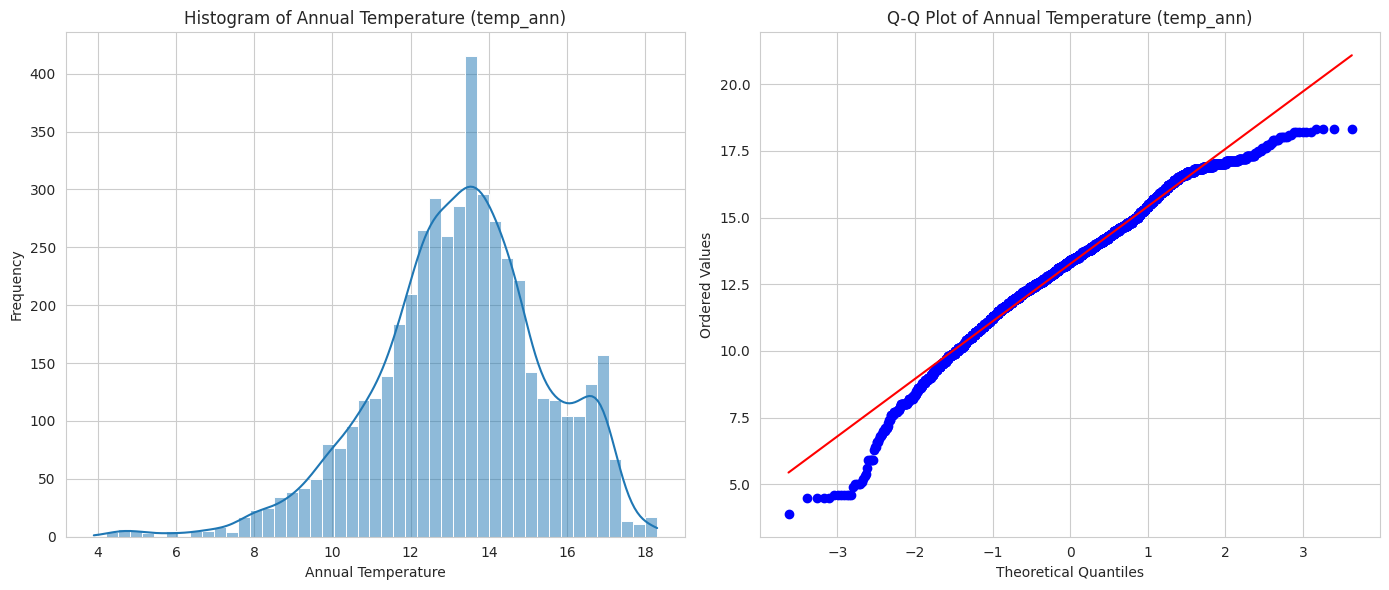


--- Shapiro-Wilk Test for Normality on temp_ann ---
Test Statistic = 0.983
P-value = 9.278e-24
Result: P-value (9.278e-24) <= alpha (0.05), so we Reject the Null Hypothesis.
Conclusion: The data does NOT appear to be normally distributed.


In [20]:
from scipy import stats

# Filter out NaN values from 'temp_ann' for accurate calculations
temp_ann_filtered = df['temp_ann'].dropna()

# --- Graphical Methods ---
plt.figure(figsize=(14, 6))

# Histogram with KDE
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(temp_ann_filtered, kde=True)
plt.title('Histogram of Annual Temperature (temp_ann)')
plt.xlabel('Annual Temperature')
plt.ylabel('Frequency')

# Q-Q Plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
stats.probplot(temp_ann_filtered, dist="norm", plot=plt)
plt.title('Q-Q Plot of Annual Temperature (temp_ann)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

plt.tight_layout()
plt.show()

# --- Statistical Method: Shapiro-Wilk Test ---
# The Shapiro-Wilk test tests the null hypothesis that the data was drawn from a normal distribution.
shapiro_stat, shapiro_p = stats.shapiro(temp_ann_filtered)

print(f"\n--- Shapiro-Wilk Test for Normality on temp_ann ---")
print(f"Test Statistic = {shapiro_stat:.3f}")
print(f"P-value = {shapiro_p:.3e}") # Display p-value in scientific notation for very small values

alpha = 0.05 # Significance level
if shapiro_p > alpha:
    print(f"Result: P-value ({shapiro_p:.3e}) > alpha ({alpha}), so we Fail to Reject the Null Hypothesis.")
    print("Conclusion: The data appears to be normally distributed (or we do not have sufficient evidence to say it's not normal).")
else:
    print(f"Result: P-value ({shapiro_p:.3e}) <= alpha ({alpha}), so we Reject the Null Hypothesis.")
    print("Conclusion: The data does NOT appear to be normally distributed.")

# Statistical explanation:
#   - Histogram: A bell-shaped, symmetric histogram suggests normality. The KDE (Kernel Density Estimate) curve helps visualize the distribution's shape.
#   - Q-Q Plot (Quantile-Quantile Plot): If the data points fall approximately along the 45-degree line, it suggests a normal distribution.
#   - Shapiro-Wilk Test: This is a statistical test for normality. The null hypothesis (H0) is that the data is normally distributed. The alternative hypothesis (H1) is that the data is not normally distributed.
#     - If p > alpha (e.g., 0.05), we fail to reject H0, suggesting the data is consistent with a normal distribution.
#     - If p <= alpha, we reject H0, suggesting the data is not normally distributed.

### 4. Performing bootstrap sampling, computing sample means, and testing their distribution

Bootstrap sampling is a resampling technique used to estimate the sampling distribution of a statistic (like the mean) by drawing many samples with replacement from the observed data. This helps us understand the variability and construct confidence intervals for our estimates.

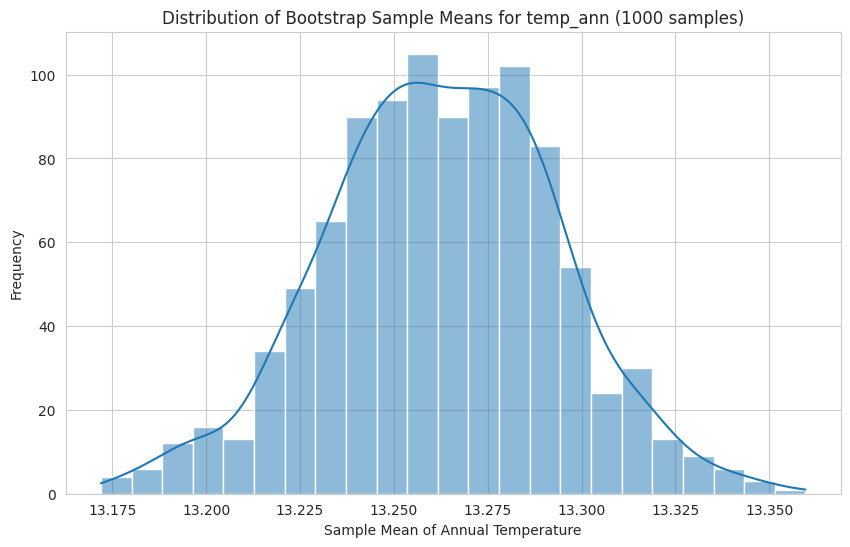


--- Bootstrap Results ---
Original sample mean of temp_ann: 13.262
Mean of bootstrap sample means: 13.263
Standard error of the mean (estimated from bootstrap): 0.031
95% Bootstrap Confidence Interval for the mean: [13.198, 13.322]


In [21]:
# Filter out NaN values from 'temp_ann' for accurate calculations
temp_ann_filtered = df['temp_ann'].dropna()

# Number of bootstrap samples
n_bootstraps = 1000

# Size of each bootstrap sample (can be the same as original dataset size or smaller)
sample_size = len(temp_ann_filtered)

# List to store bootstrap sample means
bootstrap_means = []

# Perform bootstrap sampling
for _ in range(n_bootstraps):
    # Draw a sample with replacement
    bootstrap_sample = np.random.choice(temp_ann_filtered, size=sample_size, replace=True)
    # Compute the mean of the bootstrap sample
    bootstrap_mean = np.mean(bootstrap_sample)
    bootstrap_means.append(bootstrap_mean)

# Plot the distribution of bootstrap sample means
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_means, kde=True)
plt.title(f'Distribution of Bootstrap Sample Means for temp_ann ({n_bootstraps} samples)')
plt.xlabel('Sample Mean of Annual Temperature')
plt.ylabel('Frequency')
plt.show()

# Calculate confidence interval for the mean (e.g., 95% confidence interval)
confidence_interval = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"\n--- Bootstrap Results ---")
print(f"Original sample mean of temp_ann: {np.mean(temp_ann_filtered):.3f}")
print(f"Mean of bootstrap sample means: {np.mean(bootstrap_means):.3f}")
print(f"Standard error of the mean (estimated from bootstrap): {np.std(bootstrap_means):.3f}")
print(f"95% Bootstrap Confidence Interval for the mean: [{confidence_interval[0]:.3f}, {confidence_interval[1]:.3f}]")

# Statistical explanation:
#   - Bootstrap Sampling: By repeatedly drawing samples with replacement from the original data and computing a statistic (like the mean), we create an empirical distribution of that statistic.
#   - Distribution of Sample Means: According to the Central Limit Theorem (CLT), the distribution of sample means will tend to be normally distributed, regardless of the original population distribution, as the number of samples and sample size increase.
#   - Confidence Interval: The confidence interval (e.g., 95%) is derived from the percentile range of the bootstrap distribution of the statistic. It provides a range within which the true population parameter (e.g., mean) is likely to fall.

The exploratory analysis suggests that Mean Annual Temperature influences the presence of Salmo trutta fario, with noticeable differences between presence and absence sites.

This effect is not consistent across catchments, as indicated by the comparison between Minho and Tagus, highlighting potential regional variability in environmental controls on species occurrence.

### Assessing Normality of a Variable

We'll assess the normality of the `temp_ann` variable using both graphical and statistical methods. Normality is a common assumption for many statistical tests, so it's good practice to check it.

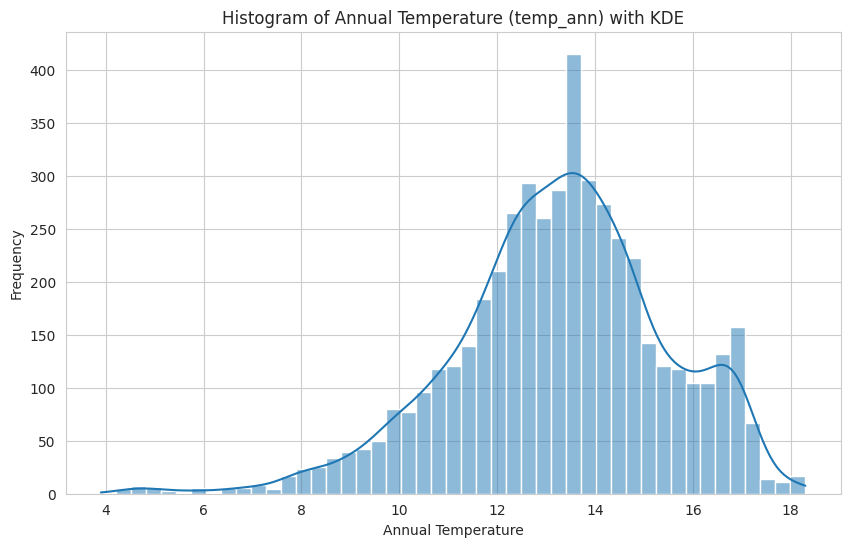


--- Interpretation of Histogram with KDE ---
A histogram visually represents the distribution of a variable. The Kernel Density Estimate (KDE) curve is a smoothed version of the histogram.
If the histogram (and KDE curve) approximates a bell-shaped, symmetric curve, it suggests that the data may be normally distributed. Deviations from this shape (e.g., skewness, multiple peaks) indicate non-normality.


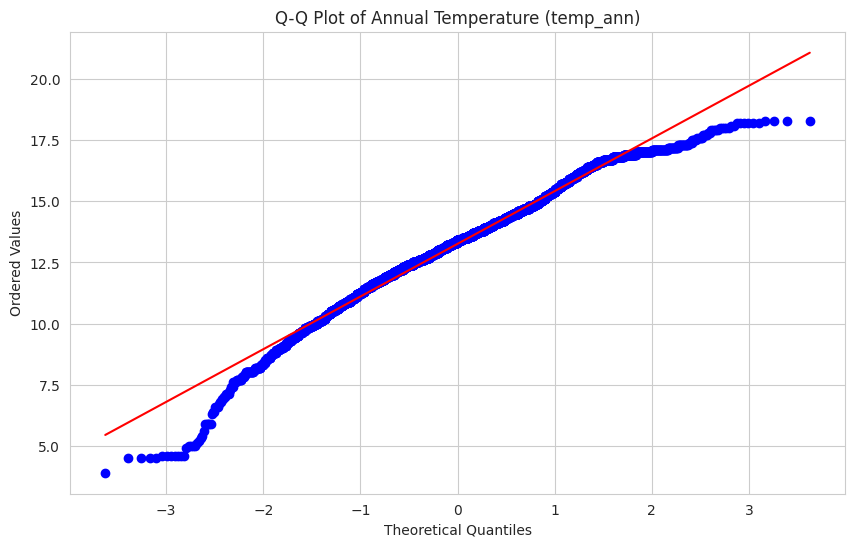


--- Interpretation of Q-Q Plot ---
A Quantile-Quantile (Q-Q) plot compares the quantiles of your data against the quantiles of a theoretical normal distribution.
If the data points fall approximately along the 45-degree reference line, it indicates that the data is normally distributed. Deviations from this line (e.g., S-shapes, curved tails) suggest non-normality.

--- Interpretation of Shapiro-Wilk Test ---
The Shapiro-Wilk test is a statistical test that assesses the null hypothesis (H0) that the data is normally distributed. The alternative hypothesis (H1) is that the data is not normally distributed.
Test Statistic = 0.983
P-value = 9.278e-24
Result: P-value (9.278e-24) <= alpha (0.05), so we Reject the Null Hypothesis.
Conclusion: The data does NOT appear to be normally distributed (i.e., it is significantly different from a normal distribution).


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Filter out NaN values from 'temp_ann' for accurate calculations
temp_ann_filtered = df['temp_ann'].dropna()

# --- 1) Histogram with KDE ---
plt.figure(figsize=(10, 6))
sns.histplot(temp_ann_filtered, kde=True)
plt.title('Histogram of Annual Temperature (temp_ann) with KDE')
plt.xlabel('Annual Temperature')
plt.ylabel('Frequency')
plt.show()

print("\n--- Interpretation of Histogram with KDE ---")
print("A histogram visually represents the distribution of a variable. The Kernel Density Estimate (KDE) curve is a smoothed version of the histogram.")
print("If the histogram (and KDE curve) approximates a bell-shaped, symmetric curve, it suggests that the data may be normally distributed. Deviations from this shape (e.g., skewness, multiple peaks) indicate non-normality.")

# --- 2) Q-Q Plot ---
plt.figure(figsize=(10, 6))
stats.probplot(temp_ann_filtered, dist="norm", plot=plt)
plt.title('Q-Q Plot of Annual Temperature (temp_ann)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

print("\n--- Interpretation of Q-Q Plot ---")
print("A Quantile-Quantile (Q-Q) plot compares the quantiles of your data against the quantiles of a theoretical normal distribution.")
print("If the data points fall approximately along the 45-degree reference line, it indicates that the data is normally distributed. Deviations from this line (e.g., S-shapes, curved tails) suggest non-normality.")

# --- 3) Shapiro-Wilk Test ---
shapiro_stat, shapiro_p = stats.shapiro(temp_ann_filtered)

print(f"\n--- Interpretation of Shapiro-Wilk Test ---")
print("The Shapiro-Wilk test is a statistical test that assesses the null hypothesis (H0) that the data is normally distributed. The alternative hypothesis (H1) is that the data is not normally distributed.")
print(f"Test Statistic = {shapiro_stat:.3f}")
print(f"P-value = {shapiro_p:.3e}")

alpha = 0.05 # Commonly used significance level
if shapiro_p > alpha:
    print(f"Result: P-value ({shapiro_p:.3e}) > alpha ({alpha}), so we Fail to Reject the Null Hypothesis.")
    print("Conclusion: There is no significant evidence to suggest that the data is not normally distributed (i.e., it appears normal).")
else:
    print(f"Result: P-value ({shapiro_p:.3e}) <= alpha ({alpha}), so we Reject the Null Hypothesis.")
    print("Conclusion: The data does NOT appear to be normally distributed (i.e., it is significantly different from a normal distribution).")

Both graphical methods and the Shapiro-Wilk test indicate that actual_river_slope does not follow a normal distribution, suggesting deviations from normality in the original data.

### Performing Bootstrap Sampling and Analyzing Sample Means

We will perform bootstrap sampling on the `temp_ann` variable to generate a distribution of sample means. This will allow us to observe how the distribution of sample means behaves, particularly in the context of the Central Limit Theorem.

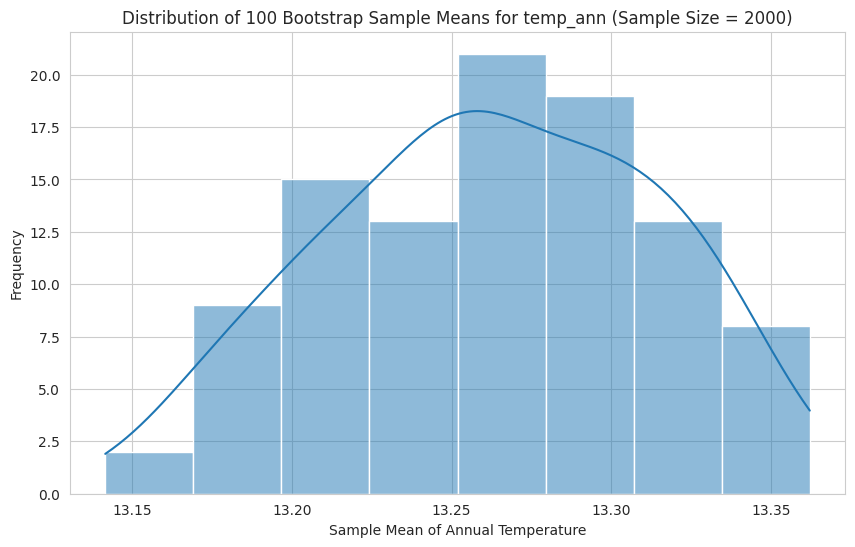


--- Shapiro-Wilk Test for Normality on Bootstrap Sample Means ---
Test Statistic = 0.982
P-value = 0.200
Result: P-value (0.200) > alpha (0.05), so we Fail to Reject the Null Hypothesis.
Conclusion: The distribution of bootstrap sample means appears to be normally distributed.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure 'temp_ann_filtered' is available and cleaned from previous steps
if 'df' not in locals() or 'temp_ann' not in df.columns:
    print("DataFrame 'df' or 'temp_ann' column not found. Please ensure data is loaded.")
    # As a fallback, try to reload if df is not defined
    # This part would typically be handled by preceding cells already run
    # For this example, assuming df and temp_ann_filtered exist.
    temp_ann_filtered = np.array([]) # Initialize as empty to prevent errors
else:
    temp_ann_filtered = df['temp_ann'].dropna().values # Convert to numpy array for efficiency

if len(temp_ann_filtered) == 0:
    print("No valid data in 'temp_ann' after dropping NaNs. Cannot perform bootstrap sampling.")
else:
    # Define parameters for bootstrap sampling
    n_bootstraps = 100 # Number of bootstrap samples
    sample_size = 2000 # Size of each bootstrap sample

    # Check if original data has enough elements for the desired sample size
    if len(temp_ann_filtered) < sample_size:
        print(f"Warning: Original data size ({len(temp_ann_filtered)}) is less than desired sample size ({sample_size}). Adjusting sample_size to {len(temp_ann_filtered)}.")
        sample_size = len(temp_ann_filtered)

    # List to store bootstrap sample means
    bootstrap_means = []

    # Perform bootstrap sampling
    for _ in range(n_bootstraps):
        # Draw a sample with replacement
        bootstrap_sample = np.random.choice(temp_ann_filtered, size=sample_size, replace=True)
        # Compute the mean of the bootstrap sample
        bootstrap_mean = np.mean(bootstrap_sample)
        bootstrap_means.append(bootstrap_mean)

    # Plot the distribution of bootstrap sample means
    plt.figure(figsize=(10, 6))
    sns.histplot(bootstrap_means, kde=True)
    plt.title(f'Distribution of {n_bootstraps} Bootstrap Sample Means for temp_ann (Sample Size = {sample_size})')
    plt.xlabel('Sample Mean of Annual Temperature')
    plt.ylabel('Frequency')
    plt.show()

    # Test normality of the bootstrap sample means using Shapiro-Wilk test
    shapiro_stat_means, shapiro_p_means = stats.shapiro(bootstrap_means)

    print(f"\n--- Shapiro-Wilk Test for Normality on Bootstrap Sample Means ---")
    print(f"Test Statistic = {shapiro_stat_means:.3f}")
    print(f"P-value = {shapiro_p_means:.3f}")

    alpha = 0.05 # Significance level
    if shapiro_p_means > alpha:
        print(f"Result: P-value ({shapiro_p_means:.3f}) > alpha ({alpha}), so we Fail to Reject the Null Hypothesis.")
        print("Conclusion: The distribution of bootstrap sample means appears to be normally distributed.")
    else:
        print(f"Result: P-value ({shapiro_p_means:.3f}) <= alpha ({alpha}), so we Reject the Null Hypothesis.")
        print("Conclusion: The distribution of bootstrap sample means does NOT appear to be normally distributed (which would be unexpected given the CLT).")


### Explanation: Central Limit Theorem Demonstration

This exercise directly demonstrates the **Central Limit Theorem (CLT)**. The CLT states that, regardless of the distribution of the population from which the samples are drawn, the distribution of sample means will tend to be normally distributed, provided the sample size is sufficiently large. This holds true even if the original population distribution (in our case, `temp_ann`) is not normal.

Here's how our results illustrate the CLT:

1.  **Original Distribution:** We previously found that the `temp_ann` variable itself is **not normally distributed** (as indicated by the histogram, Q-Q plot, and Shapiro-Wilk test).

2.  **Bootstrap Sampling:** We repeatedly draw samples (bootstraps) from this non-normal `temp_ann` distribution and calculate the mean of each sample. By repeating this many times (100 in this case), we build a new distribution: the distribution of these sample means.

3.  **Histogram of Sample Means:** The histogram of the `bootstrap_means` is expected to show a **bell-shaped curve**, characteristic of a normal distribution. This visual evidence supports the CLT.

4.  **Normality Test of Sample Means:** The Shapiro-Wilk test on the `bootstrap_means` is expected to yield a **high p-value (greater than 0.05)**. This statistical evidence would indicate that we *fail to reject the null hypothesis* that the distribution of sample means is normal, thereby confirming the CLT's prediction. *Note: If the p-value is still low, it might suggest that the number of bootstraps (100) or the sample size (2000) might need to be increased further to fully observe the normal distribution of means, or that the original distribution is extremely non-normal and requires even larger numbers.*

In essence, even though the individual annual temperature readings might not follow a normal pattern, the average annual temperature across many sufficiently large samples *will* tend to be normally distributed. This is a fundamental concept in statistics, allowing us to use parametric statistical tests (which often assume normality) on sample means, even when dealing with non-normal raw data.